In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [9]:
sns.set_theme(style="whitegrid", context="notebook")

In [10]:
pool= pd.read_parquet("../../data/engineered/swapsEngineered.parquet")

In [11]:
cex = pd.read_csv("../../data/raw/coinbase_candles.csv")

In [12]:
cex = cex.set_index("timestamp")
cex.index = pd.to_datetime(cex.index)

In [13]:
cex.head()

,open,high,low,close,volume
timestamp,,,,,
2021-05-05 00:00:00+00:00,3239.61,3249.78,3230.80,3234.14,1012.786517
2021-05-05 00:01:00+00:00,3234.46,3235.66,3209.21,3210.48,973.980393
2021-05-05 00:02:00+00:00,3209.82,3222.09,3201.33,3212.59,1290.689125
2021-05-05 00:03:00+00:00,3212.46,3247.07,3211.18,3246.86,1693.306281
2021-05-05 00:04:00+00:00,3247.14,3277.03,3246.73,3266.41,1071.470210


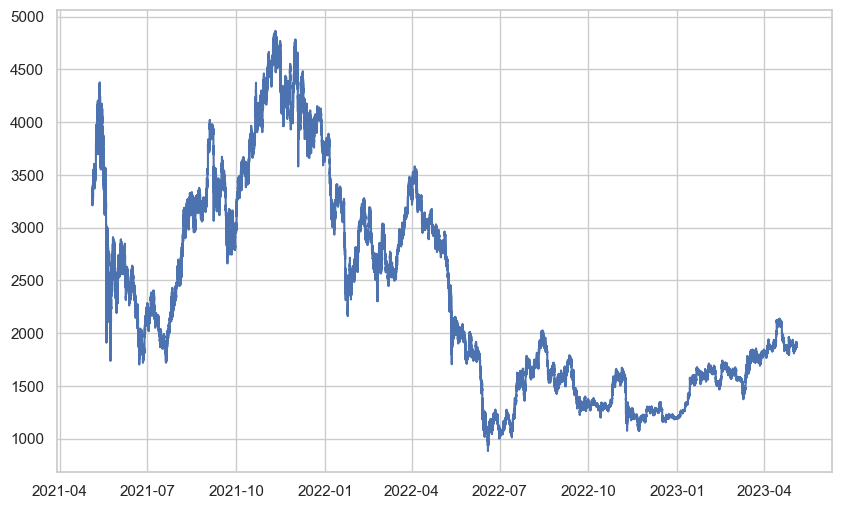

In [14]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(cex["close"])

In [15]:
pool.head()

,block_number,tx_hash,log_index,tx_index,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick,price_weth_per_usdc,price_usdc_per_weth
block_timestamp,,,,,,,,,,,,,
2021-05-05 01:56:23,12371376,ce7c3c307d820785caa12938012372fc9366a614a6aacf...,26,20,0xE592427A0AEce92De3Edee1F18E0157C05861564,0x5Eefc9306f11a824762CcDaedaC41049EFc7fcc8,-329608,100000000000000,1377932816571815120446551350158799,4303369674465501,195285.0,0.000302,3306.001763
2021-05-05 08:23:26,12373132,9a1c51b0bffbf840948f3b6e3f3e495ba1cd3fa64854f9...,192,172,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xE592427A0AEce92De3Edee1F18E0157C05861564,-164694492,50000000000000000,1378850591292581266780357299649652,4303369674465501,195298.0,0.000303,3301.602222
2021-05-05 09:50:51,12373520,c58715c62a5bf70a6ca09f0e51546d6cad76c8d4fff036...,8,18,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xFB36693ac2DBE8DFC9f89dD0de6015c6Ea66b0BF,-329169,100000000000000,1378852426842022799073024911548633,4303369674465501,195298.0,0.000303,3301.593431
2021-05-05 11:59:57,12374077,288c21b8b4fbf449b1d086a06e43b124ac2bc088c3f536...,86,102,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xFB36693ac2DBE8DFC9f89dD0de6015c6Ea66b0BF,2,-329169,1378852426842016741051966412054516,4304946248093346,195298.0,0.000303,3301.593431
2021-05-05 12:56:56,12374320,67502d8ba373287f6d301f6baa77c5a5f4c80d0753c34c...,257,115,0xE592427A0AEce92De3Edee1F18E0157C05861564,0x22F9dCF4647084d6C31b2765F6910cd85C178C18,1559137299,-467880854065813753,1370241555019945317645788135487819,4304946248093346,195173.0,0.000299,3343.219561


In [16]:
pool.tail()

,block_number,tx_hash,log_index,tx_index,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick,price_weth_per_usdc,price_usdc_per_weth
block_timestamp,,,,,,,,,,,,,
2023-05-01 22:41:59,17169010,4e0831cf426b1cc31970ad8087dee634615bcb14dab822...,295,100,0xEf1c6E67703c7BD7107eed8303Fbe6EC2554BF6B,0xEf1c6E67703c7BD7107eed8303Fbe6EC2554BF6B,1000418223,-545702874367506738,1853184361860504694859447587542481,7220734490109797848,201211.0,0.000547,1827.771554
2023-05-01 22:41:59,17169010,18bc64e1b075149e72ffae143f276272a9780feb351d10...,96,10,0x9507c04B10486547584C37bCBd931B2a4FeE9A41,0x9507c04B10486547584C37bCBd931B2a4FeE9A41,80076188079,-43690978601626828896,1853190349483519238435405559514054,7220734490109797848,201211.0,0.000547,1827.759743
2023-05-01 22:42:11,17169011,7d2949b5aaab2be54a26acdb1924d4274de1773fecdc78...,312,111,0xEf1c6E67703c7BD7107eed8303Fbe6EC2554BF6B,0xEf1c6E67703c7BD7107eed8303Fbe6EC2554BF6B,2750000000,-1500037378068968455,1853167902980133189597396863822940,7220734490109797848,201211.0,0.000547,1827.804021
2023-05-01 22:42:35,17169013,8dc9cd84db2e7706b87a9cf3e852ab728098c6b2785456...,379,131,0xEf1c6E67703c7BD7107eed8303Fbe6EC2554BF6B,0xEf1c6E67703c7BD7107eed8303Fbe6EC2554BF6B,79000000,-43091589149224649,1853167430165707899634100021047219,7220734490109797848,201211.0,0.000547,1827.804953
2023-05-01 23:01:47,17169107,f065f9757ff64b3821e9e02aa4d4778bdff44235f7a8c4...,401,159,0xEf1c6E67703c7BD7107eed8303Fbe6EC2554BF6B,0xEf1c6E67703c7BD7107eed8303Fbe6EC2554BF6B,20000000000,-10908555686755352200,1853047738072897959806410478502663,7220734490109797848,201210.0,0.000547,1828.041084


In [17]:
pool = pool.rename_axis("timestamp")

In [18]:
pool.index = pd.to_datetime(pool.index)

In [21]:
cex_r = cex.rename(columns={"close": "cex_close"})

In [25]:
cex_r.index = pd.to_datetime(cex_r.index)

In [23]:
cex_r.index.dtype

datetime64[ns, UTC]

In [27]:
pool.index = pool.index.tz_localize("UTC")

In [33]:
pool_s = pool.sort_index()
cex_s = cex_r.sort_index()

df = pd.merge_asof(
    pool_s.reset_index().sort_values("timestamp"),
    cex_s.reset_index().sort_values("timestamp"),
    on="timestamp",
    direction="backward",         
    tolerance=pd.Timedelta("1min"),    
)

df = df.set_index("timestamp")

In [34]:
df.head()

,block_number,tx_hash,log_index,tx_index,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick,price_weth_per_usdc,price_usdc_per_weth,open,high,low,cex_close,volume
timestamp,,,,,,,,,,,,,,,,,,
2021-05-05 01:56:23+00:00,12371376,ce7c3c307d820785caa12938012372fc9366a614a6aacf...,26,20,0xE592427A0AEce92De3Edee1F18E0157C05861564,0x5Eefc9306f11a824762CcDaedaC41049EFc7fcc8,-329608,100000000000000,1377932816571815120446551350158799,4303369674465501,195285.0,0.000302,3306.001763,3370.67,3372.02,3365.56,3367.93,129.824019
2021-05-05 08:23:26+00:00,12373132,9a1c51b0bffbf840948f3b6e3f3e495ba1cd3fa64854f9...,192,172,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xE592427A0AEce92De3Edee1F18E0157C05861564,-164694492,50000000000000000,1378850591292581266780357299649652,4303369674465501,195298.0,0.000303,3301.602222,3353.05,3353.31,3345.00,3346.97,67.672678
2021-05-05 09:50:51+00:00,12373520,c58715c62a5bf70a6ca09f0e51546d6cad76c8d4fff036...,8,18,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xFB36693ac2DBE8DFC9f89dD0de6015c6Ea66b0BF,-329169,100000000000000,1378852426842022799073024911548633,4303369674465501,195298.0,0.000303,3301.593431,3366.64,3372.42,3366.63,3369.56,59.268102
2021-05-05 11:59:57+00:00,12374077,288c21b8b4fbf449b1d086a06e43b124ac2bc088c3f536...,86,102,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xFB36693ac2DBE8DFC9f89dD0de6015c6Ea66b0BF,2,-329169,1378852426842016741051966412054516,4304946248093346,195298.0,0.000303,3301.593431,3353.64,3355.86,3351.83,3354.78,84.239089
2021-05-05 12:56:56+00:00,12374320,67502d8ba373287f6d301f6baa77c5a5f4c80d0753c34c...,257,115,0xE592427A0AEce92De3Edee1F18E0157C05861564,0x22F9dCF4647084d6C31b2765F6910cd85C178C18,1559137299,-467880854065813753,1370241555019945317645788135487819,4304946248093346,195173.0,0.000299,3343.219561,3382.10,3382.10,3378.66,3378.66,123.910237


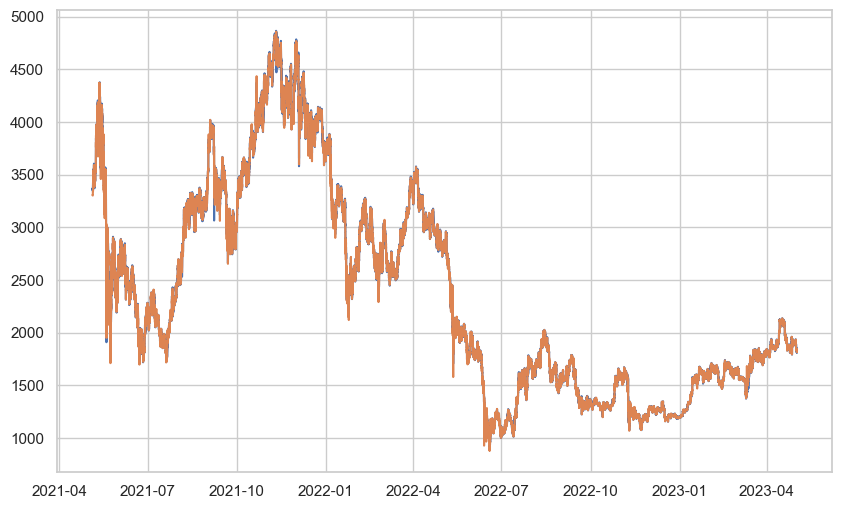

In [37]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(df["cex_close"])
ax.plot(df["price_usdc_per_weth"])

## Now to compute Trade-Based LVR

In [41]:
df["amount1"].dtype

string[python]

In [43]:
df["amount1"] = df["amount1"].astype(float)

In [44]:
df["amount1"].dtype

dtype('float64')

In [45]:
df["q_weth"] = -df["amount1"]

In [47]:
df.head()

,block_number,tx_hash,log_index,tx_index,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick,price_weth_per_usdc,price_usdc_per_weth,open,high,low,cex_close,volume,q_weth
timestamp,,,,,,,,,,,,,,,,,,,
2021-05-05 01:56:23+00:00,12371376,ce7c3c307d820785caa12938012372fc9366a614a6aacf...,26,20,0xE592427A0AEce92De3Edee1F18E0157C05861564,0x5Eefc9306f11a824762CcDaedaC41049EFc7fcc8,-329608,1.000000e+14,1377932816571815120446551350158799,4303369674465501,195285.0,0.000302,3306.001763,3370.67,3372.02,3365.56,3367.93,129.824019,-1.000000e+14
2021-05-05 08:23:26+00:00,12373132,9a1c51b0bffbf840948f3b6e3f3e495ba1cd3fa64854f9...,192,172,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xE592427A0AEce92De3Edee1F18E0157C05861564,-164694492,5.000000e+16,1378850591292581266780357299649652,4303369674465501,195298.0,0.000303,3301.602222,3353.05,3353.31,3345.00,3346.97,67.672678,-5.000000e+16
2021-05-05 09:50:51+00:00,12373520,c58715c62a5bf70a6ca09f0e51546d6cad76c8d4fff036...,8,18,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xFB36693ac2DBE8DFC9f89dD0de6015c6Ea66b0BF,-329169,1.000000e+14,1378852426842022799073024911548633,4303369674465501,195298.0,0.000303,3301.593431,3366.64,3372.42,3366.63,3369.56,59.268102,-1.000000e+14
2021-05-05 11:59:57+00:00,12374077,288c21b8b4fbf449b1d086a06e43b124ac2bc088c3f536...,86,102,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xFB36693ac2DBE8DFC9f89dD0de6015c6Ea66b0BF,2,-3.291690e+05,1378852426842016741051966412054516,4304946248093346,195298.0,0.000303,3301.593431,3353.64,3355.86,3351.83,3354.78,84.239089,3.291690e+05
2021-05-05 12:56:56+00:00,12374320,67502d8ba373287f6d301f6baa77c5a5f4c80d0753c34c...,257,115,0xE592427A0AEce92De3Edee1F18E0157C05861564,0x22F9dCF4647084d6C31b2765F6910cd85C178C18,1559137299,-4.678809e+17,1370241555019945317645788135487819,4304946248093346,195173.0,0.000299,3343.219561,3382.10,3382.10,3378.66,3378.66,123.910237,4.678809e+17


In [48]:
df["p_pool"] = df["price_usdc_per_weth"]
df["p_cex"] = df["cex_close"]

In [50]:
def lvr_row(row):
    '''
    per swap lvr computed for each side
    '''
    q = row["q_weth"]
    p_pool = row["p_pool"]
    p_cex = row["p_cex"]

    if q > 0:
        edge = p_cex - p_pool
        return max(edge, 0.0) * q
    elif q < 0:
        q_abs = -q
        edge = p_pool - p_cex
        return max(edge, 0.0) * q_abs
    else:
        return 0.0

In [51]:
df["dLVR"] = df.apply(lvr_row, axis=1)
df["LVR_cum"] = df["dLVR"].cumsum()

In [53]:
df[["q_weth","p_pool","p_cex","dLVR","LVR_cum"]].head()

,q_weth,p_pool,p_cex,dLVR,LVR_cum
timestamp,,,,,
2021-05-05 01:56:23+00:00,-1.000000e+14,3306.001763,3367.93,0.000000e+00,0.000000e+00
2021-05-05 08:23:26+00:00,-5.000000e+16,3301.602222,3346.97,0.000000e+00,0.000000e+00
2021-05-05 09:50:51+00:00,-1.000000e+14,3301.593431,3369.56,0.000000e+00,0.000000e+00
2021-05-05 11:59:57+00:00,3.291690e+05,3301.593431,3354.78,1.750737e+07,1.750737e+07
2021-05-05 12:56:56+00:00,4.678809e+17,3343.219561,3378.66,1.658190e+19,1.658190e+19


Text(0, 0.5, 'LVR')

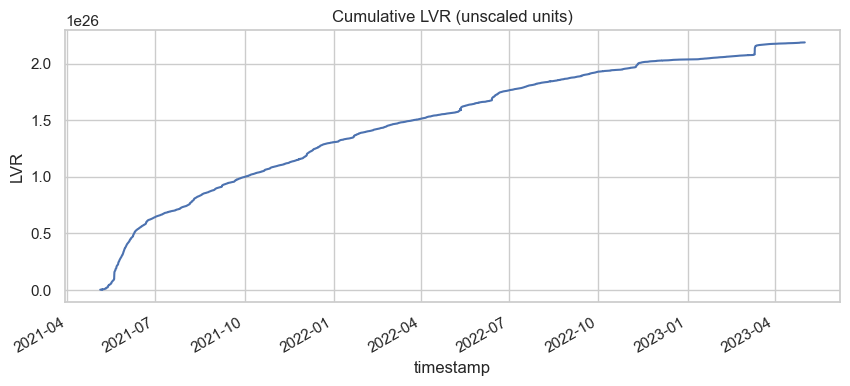

In [55]:
fig, ax = plt.subplots(figsize=(10,4))
df["LVR_cum"].plot(ax=ax)
ax.set_title("Cumulative LVR (unscaled units)")
ax.set_ylabel("LVR")

Text(0, 0.5, 'LVR')

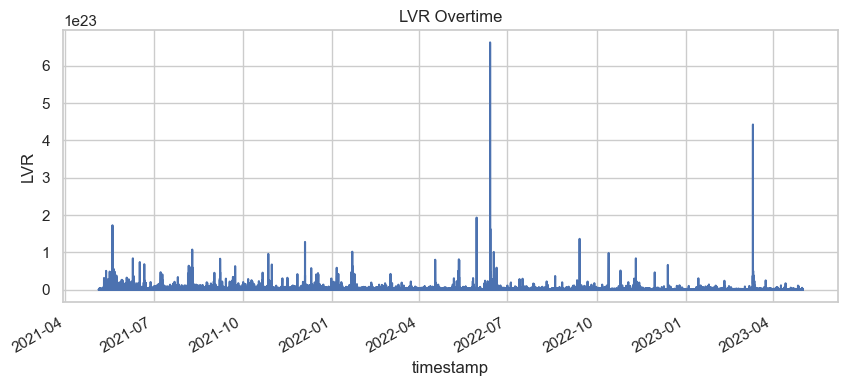

In [57]:
fig, ax = plt.subplots(figsize=(10,4))
df["dLVR"].plot(ax=ax)
ax.set_title("LVR Overtime")
ax.set_ylabel("LVR")

In [58]:
DEC_WETH = 18  # convert to WETH maybe instead of wei
df["q_weth_eth"] = df["q_weth"] / 10**DEC_WETH

df["dLVR_usd"] = df.apply(
    lambda row: max(row["p_cex"] - row["p_pool"], 0) * row["q_weth_eth"]
                if row["q_weth_eth"] > 0 else
                max(row["p_pool"] - row["p_cex"], 0) * -row["q_weth_eth"],
    axis=1
)
df["LVR_cum_usd"] = df["dLVR_usd"].cumsum()

Text(0, 0.5, 'LVR')

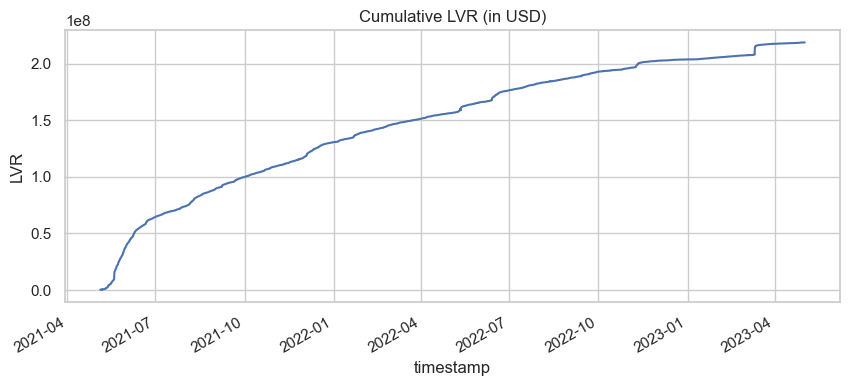

In [59]:
fig, ax = plt.subplots(figsize=(10,4))
df["LVR_cum_usd"].plot(ax=ax)
ax.set_title("Cumulative LVR (in USD)")
ax.set_ylabel("LVR")

Text(0, 0.5, 'LVR (USD)')

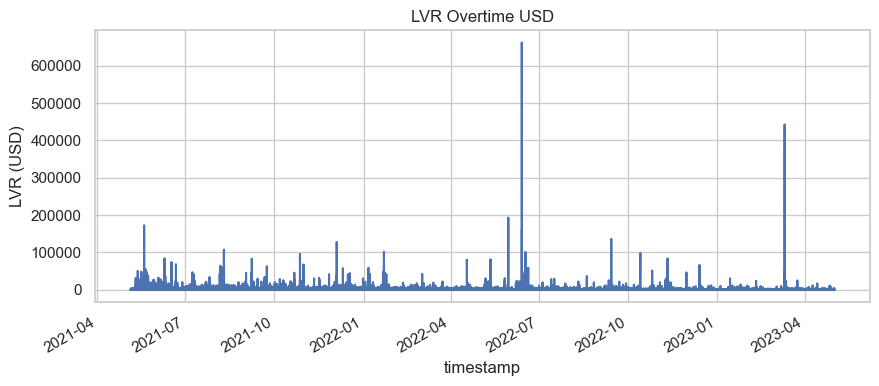

In [61]:
fig, ax = plt.subplots(figsize=(10,4))
df["dLVR_usd"].plot(ax=ax)
ax.set_title("LVR Overtime USD")
ax.set_ylabel("LVR (USD)")

In [56]:
# Timeseries lvr
lvr_hourly = df["dLVR"].resample("1H").sum()
lvr_daily  = df["dLVR"].resample("1D").sum()

/var/folders/3t/0nrchrfd79xcg6j3q6yk110m0000gn/T/ipykernel_26532/3865611709.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lvr_hourly = df["dLVR"].resample("1H").sum()


## Now the fun begins: Lets start some basic forecasting and correlation stuff

In [64]:
# Got that hourly lvr
lvr_1h = df["dLVR_usd"].resample("1H").sum()

/var/folders/3t/0nrchrfd79xcg6j3q6yk110m0000gn/T/ipykernel_26532/4276811180.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lvr_1h = df["dLVR_usd"].resample("1H").sum()


In [65]:
px = df["cex_close"]
returns = np.log(px).diff().dropna()
rv_5m = (returns**2).resample("5T").sum()
rv_1h = rv_5m.resample("1H").sum()

/var/folders/3t/0nrchrfd79xcg6j3q6yk110m0000gn/T/ipykernel_26532/3302562576.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  rv_5m = (returns**2).resample("5T").sum()
/var/folders/3t/0nrchrfd79xcg6j3q6yk110m0000gn/T/ipykernel_26532/3302562576.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rv_1h = rv_5m.resample("1H").sum()


### Simple OLS of 1hr LVR given features:
1. CEX Hourly returns
2. Basis
3. liquidity of pool

In [79]:
features = ["RV_1h", "basis_abs", "liq"]

In [80]:
from sklearn.preprocessing import StandardScaler

cols = ["RV_1h", "basis_abs", "liq"]
X_raw = data[cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X = sm.add_constant(X_scaled)
y = data["y"]

print("matrix rank after scaling:", np.linalg.matrix_rank(X))


matrix rank after scaling: 4


In [81]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     1043.
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:22:24   Log-Likelihood:                -38703.
No. Observations:               17200   AIC:                         7.741e+04
Df Residuals:                   17196   BIC:                         7.744e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.9232      0.018    452.501      0.0